In [21]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
from sklearn.model_selection import train_test_split, learning_curve
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns


In [22]:
# Load dataset
df = pd.read_csv(r"E:\Jupyter NoteBooks\TotalData.csv")
print(df)


          Acc X     Acc Y     Acc Z  Class
0     -0.594492  0.697371  0.007036    0.0
1     -0.483941  0.563351 -0.650454    0.0
2     -0.211693  0.966558 -0.282735    0.0
3     -0.723785  0.877594 -0.343555    0.0
4     -0.471551  1.006735 -0.598023    0.0
...         ...       ...       ...    ...
10018  0.199696 -0.390284  0.177963    2.0
10019  1.054241 -0.293285  0.050729    2.0
10020  0.191436 -0.501346  0.664527    2.0
10021 -0.480446 -1.136146  0.647049    2.0
10022  0.719094 -0.798657 -0.109362    2.0

[10023 rows x 4 columns]


In [3]:
# Split data into features and target
X = df[['Acc X', 'Acc Y', 'Acc Z']]
y = df['Class']


In [4]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)


In [5]:
# Apply SMOTE to balance classes in training data
smote = SMOTE(random_state=2)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


In [6]:
# Train the model with SVM algorithm
svm = SVC(kernel='rbf', C=2, gamma='scale', probability=True, random_state=2)
svm.fit(X_train_resampled, y_train_resampled)


SVC(C=2, probability=True, random_state=2)

In [7]:
# Predict on training and testing data
y_train_pred = svm.predict(X_train)
y_test_pred = svm.predict(X_test)


In [8]:
# Get predicted probabilities for training and testing data
y_train_pred_prob = svm.predict_proba(X_train)
y_test_pred_prob = svm.predict_proba(X_test)


In [9]:
# Compute ROC curve and ROC AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = y_test.nunique()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test == i, y_test_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    

In [10]:
# Compute macro-average ROC AUC
fpr["macro"], tpr["macro"], _ = roc_curve(pd.get_dummies(y_test).values.ravel(), y_test_pred_prob.ravel())
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])


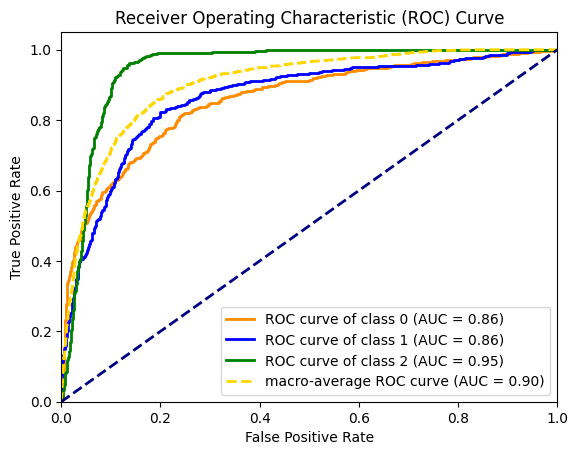

In [11]:
# Plot ROC curves
plt.figure()
lw = 2
colors = ['darkorange', 'blue', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw, label='ROC curve of class {0} (AUC = {1:0.2f})'
             ''.format(i, roc_auc[i]))
    
plt.plot(fpr["macro"], tpr["macro"], color='gold', lw=lw, linestyle='--', label='macro-average ROC curve (AUC = {0:0.2f})'
        ''.format(roc_auc["macro"]))

plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


In [12]:
# Print training and testing accuracy
train_acc = np.mean(y_train_pred == y_train)
test_acc = np.mean(y_test_pred == y_test)
print(f"Training accuracy: {train_acc}")
print(f"Testing accuracy: {test_acc}")

Training accuracy: 0.7463207782489398
Testing accuracy: 0.7541147132169576


In [13]:
# Print training and testing confusion matrix
train_cm = confusion_matrix(y_train, y_train_pred)
test_cm = confusion_matrix(y_test, y_test_pred)
print("Training confusion matrix:\n", train_cm)
print("Testing confusion matrix:\n", test_cm)

Training confusion matrix:
 [[1395  897  374]
 [ 230 2064  387]
 [  53   93 2525]]
Testing confusion matrix:
 [[356 217 102]
 [ 62 513  85]
 [ 13  14 643]]


In [14]:
# Print training and testing f1 score
train_f1 = f1_score(y_train, y_train_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')
print(f"Training f1 score: {train_f1}")
print(f"Testing f1 score: {test_f1}")

Training f1 score: 0.7366372308925995
Testing f1 score: 0.7437705259270334


In [15]:
# Print training and testing classification report
train_report = classification_report(y_train, y_train_pred)
test_report = classification_report(y_test, y_test_pred)
print("Training classification report:\n", train_report)
print("Testing classification report:\n", test_report)

Training classification report:
               precision    recall  f1-score   support

         0.0       0.83      0.52      0.64      2666
         1.0       0.68      0.77      0.72      2681
         2.0       0.77      0.95      0.85      2671

    accuracy                           0.75      8018
   macro avg       0.76      0.75      0.74      8018
weighted avg       0.76      0.75      0.74      8018

Testing classification report:
               precision    recall  f1-score   support

         0.0       0.83      0.53      0.64       675
         1.0       0.69      0.78      0.73       660
         2.0       0.77      0.96      0.86       670

    accuracy                           0.75      2005
   macro avg       0.76      0.75      0.74      2005
weighted avg       0.76      0.75      0.74      2005



In [16]:
# Print overall performance metrics
print(f"Overall performance metrics:")
print(f"Accuracy: {test_acc}")
print(f"F1 score: {test_f1}")
print("Confusion matrix:\n", test_cm)

Overall performance metrics:
Accuracy: 0.7541147132169576
F1 score: 0.7437705259270334
Confusion matrix:
 [[356 217 102]
 [ 62 513  85]
 [ 13  14 643]]


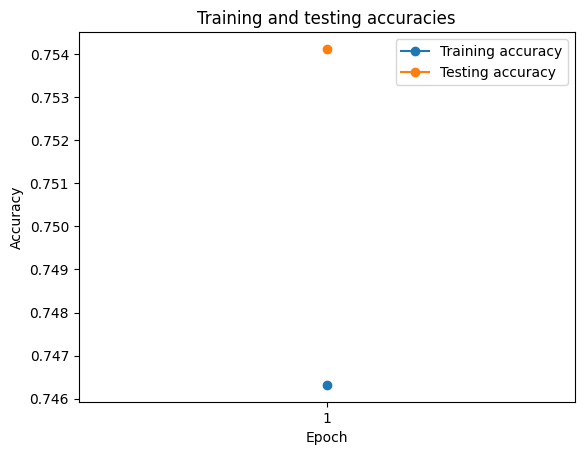

In [17]:
# Define the epochs (in this case, we only have one epoch)
epochs = [1]
# Define the training and testing accuracies
train_accs = [train_acc]
test_accs = [test_acc]
# Plot the accuracies
plt.plot(epochs, train_accs, '-o', label='Training accuracy')
plt.plot(epochs, test_accs, '-o', label='Testing accuracy')
plt.title('Training and testing accuracies')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(epochs)
plt.legend()
plt.show()

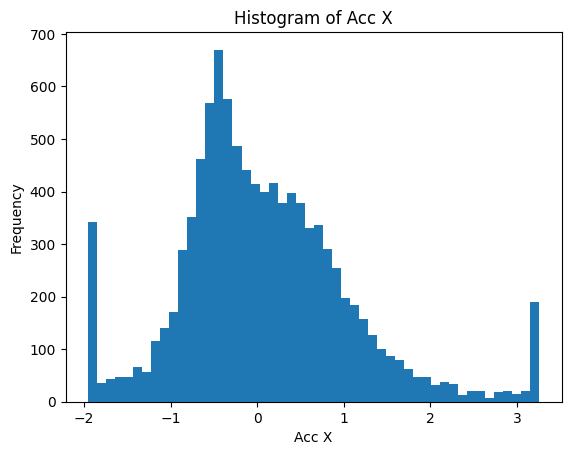

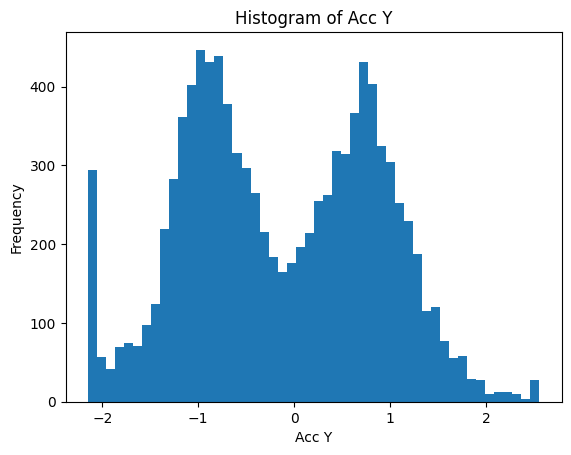

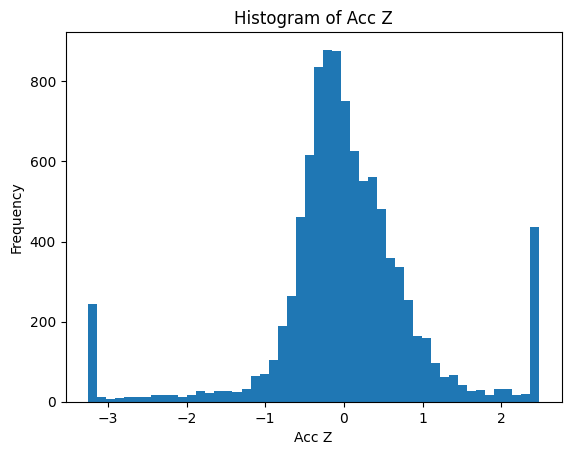

In [18]:
# Create histogram for 'Acc X' feature
plt.hist(df['Acc X'], bins=50)
plt.xlabel('Acc X')
plt.ylabel('Frequency')
plt.title('Histogram of Acc X')
plt.show()
# Create histogram for 'Acc Y' feature
plt.hist(df['Acc Y'], bins=50)
plt.xlabel('Acc Y')
plt.ylabel('Frequency')
plt.title('Histogram of Acc Y')
plt.show()
# Create histogram for 'Acc X' feature
plt.hist(df['Acc Z'], bins=50)
plt.xlabel('Acc Z')
plt.ylabel('Frequency')
plt.title('Histogram of Acc Z')
plt.show()

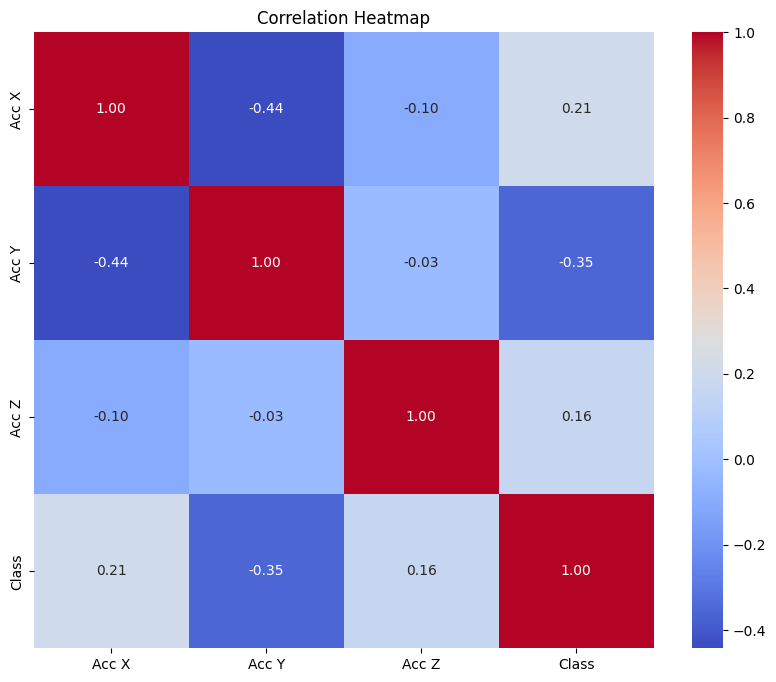

In [23]:
# Calculate correlation matrix
corr_matrix = df.corr()
# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

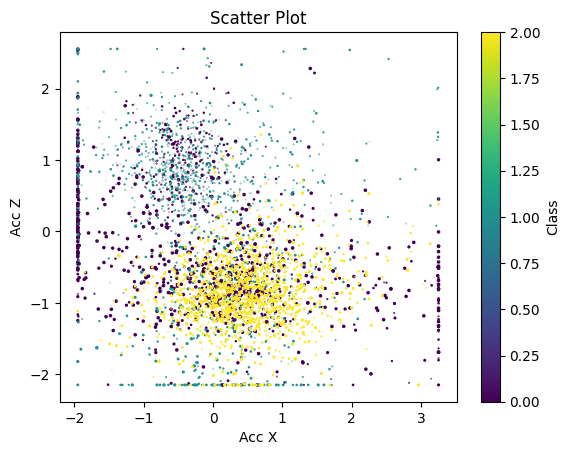

In [28]:
# Create scatter plot
plt.scatter(df['Acc X'], df['Acc Y'], df['Acc Z'], c=df['Class'])
plt.xlabel('Acc X')
plt.ylabel('Acc Y')
plt.ylabel('Acc Z')
plt.title('Scatter Plot')
plt.colorbar(label='Class')
plt.show()

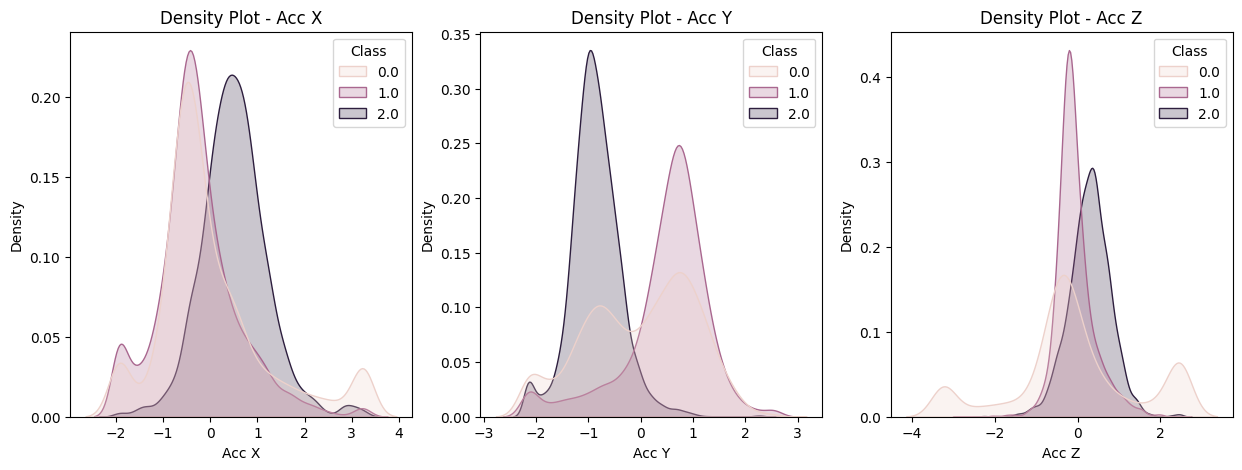

In [32]:
# Create subplots for each acceleration
fig, axs = plt.subplots(ncols=3, figsize=(15, 5))
# Plot density plot for Acc X
sns.kdeplot(data=df, x='Acc X', hue='Class', fill=True, ax=axs[0])
axs[0].set_title('Density Plot - Acc X')
# Plot density plot for Acc Y
sns.kdeplot(data=df, x='Acc Y', hue='Class', fill=True, ax=axs[1])
axs[1].set_title('Density Plot - Acc Y')
# Plot density plot for Acc Z
sns.kdeplot(data=df, x='Acc Z', hue='Class', fill=True, ax=axs[2])
axs[2].set_title('Density Plot - Acc Z')
# Show plot
plt.show()